# 0a. Detrending/deseasonalization — all 4 methods, for BOTH CESM2-FOSI and every CESM2-LENS member


In [2]:
import xarray as xr
import numpy as np
import xarray as xr
import json
from scipy import stats

In [10]:
base_paths = {
    'linear': '/glade/work/cmendiola/data_conv_lin_trend',
    'quadratic': '/glade/work/cmendiola/data_quad_trend',
    'ensmean': '/glade/work/cmendiola/data_ens_mean',
    'noseas': '/glade/work/cmendiola/data_rm_seasonalcycle_mean',
}

da_mhwobj_labels_by_method = {}
ssta_notrend_by_method = {}
# Corrected loading - use radius=1 (index 1 = 2°) for ALL FOUR methods, including ensemble mean
RADIUS_INDEX_FOR_2DEG = 1

da_mhwobj_labels_by_method = {}
ssta_notrend_by_method = {}

for method, base_path in base_paths.items():
    mhwobj_paths = [f'{base_path}/ens_{i}_mhwobj.nc' for i in range(100)]
    ssta_paths = [f'{base_path}/ens_{i}_ssta.nc' for i in range(100)]

    da_mhwobj = xr.open_mfdataset(mhwobj_paths, combine='nested', concat_dim='ensemble_member')
    da_mhwobj_labels_by_method[method] = da_mhwobj.labels.sel(radius=RADIUS_INDEX_FOR_2DEG).sel(time=slice('1979-01','2020-12')).compute()

    ssta_notrend_by_method[method] = xr.open_mfdataset(ssta_paths, combine='nested', concat_dim='ensemble_member').compute()

print("All four methods now loaded at radius index 1 (2°)")

All four methods now loaded at radius index 1 (2°)


In [11]:
# ============================================================
# STEP 2: Load the canonical footprint (mask_3)
# ============================================================
mask_3 = xr.open_dataset('mean_mask_3.nc').mhw_obj
mask_3_binary = xr.where(mask_3 > 0.1, 1, 0)

def calc_frac_overlap(one_obj, mask):
    one_obj_binary = xr.where(one_obj > 0, 1., 0)
    overlap = one_obj_binary + mask
    overlap_only = xr.where(overlap > 1, 1., 0)
    overlap_frac = overlap_only.sum(dim=('lat','lon')) / mask.sum()
    if overlap_frac.size > 0 and overlap_frac.notnull().any():
        return overlap_frac.max().item()
    return 0.0

In [12]:
# ============================================================
# STEP 3: Total number of North Pacific MHW events per method
# (needed as denominator for Fig S1a, and to report "N events" in the caption)
# ============================================================
total_events_by_method = {}

for method in base_paths:
    labels_full = da_mhwobj_labels_by_method[method]
    total_count = 0
    for member_id in range(100):
        member_labels = labels_full.isel(ensemble_member=member_id)
        unique_ids = np.unique(member_labels.max(dim=('lat','lon')).compute().data)
        unique_ids = unique_ids[~np.isnan(unique_ids)][:-1]
        total_count += len(unique_ids)
    total_events_by_method[method] = total_count

print(total_events_by_method)

{'linear': 8873, 'quadratic': 8708, 'ensmean': 8572, 'noseas': 6648}


In [13]:
# ============================================================
# STEP 4: Overlap threshold sensitivity (for Fig S1a) + Blob-analog IDs at 50% (for everything else)
# Run for ALL FOUR methods now, at the corrected radius
# ============================================================
thresholds = np.arange(0.1, 0.81, 0.1)  # index 4 = 0.5

object_id_ls_by_method = {}
counts_per_threshold_by_method = {}

for method in base_paths:
    print(f"=== {method} ===")
    labels_full = da_mhwobj_labels_by_method[method]

    object_id_ls_method = []
    counts_per_threshold_method = []

    for threshold in thresholds:
        temp_count = 0
        object_ids = []

        for member_id in range(100):
            member_labels = labels_full.isel(ensemble_member=member_id)
            unique_ids = np.unique(member_labels.max(dim=('lat','lon')).compute().data)
            unique_ids = unique_ids[~np.isnan(unique_ids)][:-1]

            object_id_member = []
            for object_id in unique_ids:
                one_obj = member_labels.where(member_labels == object_id, drop=False)
                overlap_val = calc_frac_overlap(one_obj, mask_3_binary)
                if overlap_val > threshold:
                    temp_count += 1
                    object_id_member.append(object_id)
            object_ids.append(object_id_member)

        object_id_ls_method.append(object_ids)
        counts_per_threshold_method.append(temp_count)
        print(f"  threshold {threshold:.1f}: {temp_count} events")

    object_id_ls_by_method[method] = object_id_ls_method
    counts_per_threshold_by_method[method] = counts_per_threshold_method

    with open(f'object_id_ls_greenmask_{method}_corrected.json', 'w') as f:
        json.dump(object_id_ls_method, f)

print(counts_per_threshold_by_method)

=== linear ===
  threshold 0.1: 3652 events
  threshold 0.2: 1735 events
  threshold 0.3: 919 events
  threshold 0.4: 561 events
  threshold 0.5: 331 events
  threshold 0.6: 184 events
  threshold 0.7: 90 events
  threshold 0.8: 19 events
=== quadratic ===
  threshold 0.1: 3564 events
  threshold 0.2: 1688 events
  threshold 0.3: 915 events
  threshold 0.4: 547 events
  threshold 0.5: 327 events
  threshold 0.6: 187 events
  threshold 0.7: 92 events
  threshold 0.8: 26 events
=== ensmean ===
  threshold 0.1: 3505 events
  threshold 0.2: 1628 events
  threshold 0.3: 876 events
  threshold 0.4: 530 events
  threshold 0.5: 312 events
  threshold 0.6: 166 events
  threshold 0.7: 70 events
  threshold 0.8: 25 events
=== noseas ===
  threshold 0.1: 2666 events
  threshold 0.2: 1385 events
  threshold 0.3: 795 events
  threshold 0.4: 523 events
  threshold 0.5: 343 events
  threshold 0.6: 212 events
  threshold 0.7: 118 events
  threshold 0.8: 46 events
{'linear': [3652, 1735, 919, 561, 331, 

In [14]:
# ============================================================
# STEP 5: Blob-analog IDs at 50% threshold (index 4), for downstream analysis
# ============================================================
blob_analog_ids = {method: object_id_ls_by_method[method][4] for method in base_paths}
print({m: sum(len(ids) for ids in blob_analog_ids[m]) for m in base_paths})

{'linear': 331, 'quadratic': 327, 'ensmean': 312, 'noseas': 343}


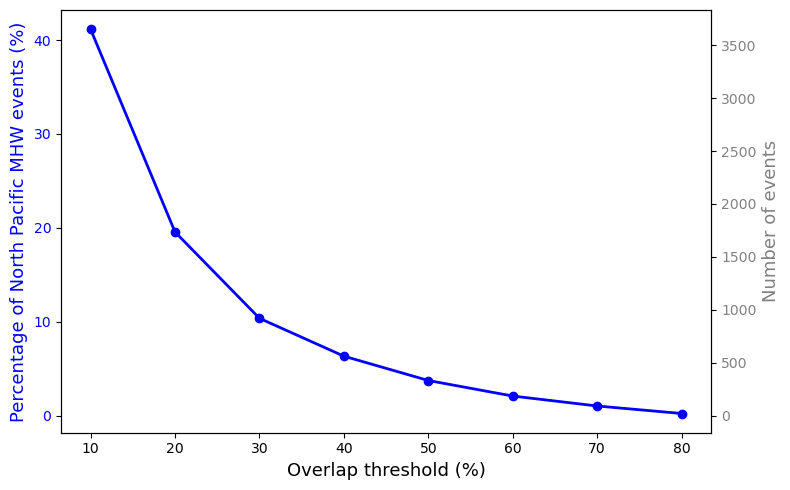

Total N events (linear method): 8873


In [15]:
# ============================================================
# STEP 6: Figure S1a - percentage + absolute count, dual y-axis
# (using the PRIMARY method - linear - as your main analysis, per Methods 2.2)
# ============================================================
import matplotlib.pyplot as plt

pct_overlap = 100 * np.array(counts_per_threshold_by_method['linear']) / total_events_by_method['linear']
total_n_events = total_events_by_method['linear']

fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(thresholds*100, pct_overlap, color='blue', linewidth=2, marker='o')
ax1.set_xlabel('Overlap threshold (%)', fontsize=13)
ax1.set_ylabel('Percentage of North Pacific MHW events (%)', fontsize=13, color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Number of events', fontsize=13, color='gray')
ax2.set_ylim(ax1.get_ylim()[0] * total_n_events / 100, ax1.get_ylim()[1] * total_n_events / 100)
ax2.tick_params(axis='y', labelcolor='gray')

plt.tight_layout()
plt.savefig('Figure_S1a.png', dpi=300)
plt.show()

print(f"Total N events (linear method): {total_n_events}")

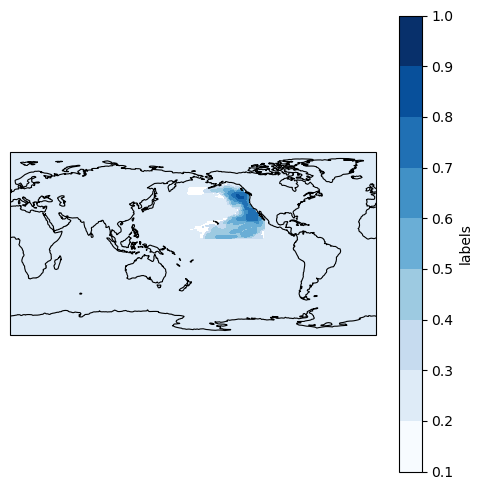

In [16]:
# ============================================================
# STEP 7: Figure S1b - canonical footprint + FOSI Blob occurrence fraction
# (fixing the date range to May 2014-Dec 2015)
# ============================================================
fosi_blobs = xr.open_dataset('fosi_blobs_r2.nc').labels

object_id = 94.
blob_times_corrected = fosi_blobs.time.where(
    (fosi_blobs == object_id).any(dim=('lat','lon')), drop=True
)
the_blob = xr.where(fosi_blobs.sel(time=blob_times_corrected) == object_id, 1., 0.)

n_months = len(blob_times_corrected)  # should be 20
fosi_blob_footprint = the_blob.sum(dim='time') / n_months  # fraction of duration present
fosi_blob_footprint_nan = xr.where(fosi_blob_footprint <= 0.1, np.nan, fosi_blob_footprint)

import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(5, 5))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
ax.add_feature(cfeature.LAND, facecolor='lightgrey', edgecolor='black', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)

im = fosi_blob_footprint_nan.plot.contourf(
    ax=ax, transform=ccrs.PlateCarree(),
    levels=np.linspace(0.1, 1.0, 10), cmap='Blues', add_colorbar=True
)
ax.set_extent([150, 250, 5, 65], crs=ccrs.PlateCarree())
mask_3.plot.contour(ax=ax, transform=ccrs.PlateCarree(), levels=[0.5], colors='green', linewidths=2)

plt.tight_layout()
plt.show()

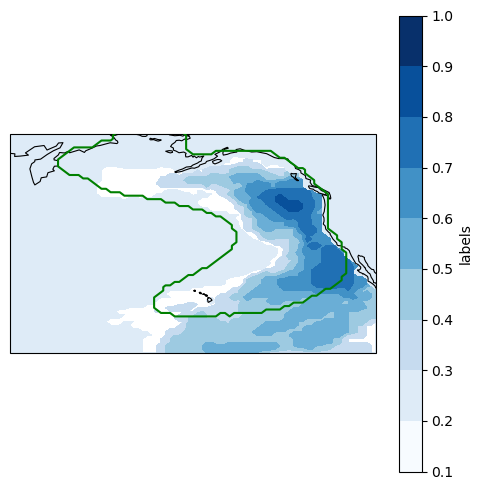

In [20]:
fig = plt.figure(figsize=(5, 5))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
ax.add_feature(cfeature.LAND, facecolor='lightgrey', edgecolor='black', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)

im = fosi_blob_footprint_nan.plot.contourf(
    ax=ax, transform=ccrs.PlateCarree(),
    levels=np.linspace(0.1, 1.0, 10), cmap='Blues', add_colorbar=True
)
ax.set_extent([150, 250, 5, 65], crs=ccrs.PlateCarree())
mask_3.plot.contour(ax=ax, transform=ccrs.PlateCarree(), levels=[0.5], colors='green', linewidths=2)
mask_3_binary.plot.contour(
            ax=ax,
            transform=ccrs.PlateCarree(),
            levels=[0.5],
            colors='green',
            linewidths=1.5,
            zorder=20
        )
plt.tight_layout()
plt.show()

In [65]:
# --- Confirmed Blob mask (Label 94, correct 20-month window) ---
object_id = 94.0
blob_times = fosi_blobs.time.where((fosi_blobs == object_id).any(dim=('lat','lon')), drop=True)
n_months = len(blob_times)  # should be 20

the_blob = xr.where(fosi_blobs.sel(time=blob_times) == object_id, 1., 0.)

# Fraction of the event's duration each grid cell was part of the footprint
fosi_blob_footprint = the_blob.sum(dim='time') / n_months

# Mask out cells present for 10% or less of the duration (per your Fig S1 caption)
# fosi_blob_footprint_nan = xr.where(fosi_blob_footprint <= 0.1, np.nan, fosi_blob_footprint)

print(f"n_months: {n_months}")  # sanity check - should print 20
print(f"Max fraction: {float(fosi_blob_footprint_nan.max()):.2f}")  # should be <= 1.0

n_months: 20
Max fraction: 0.85


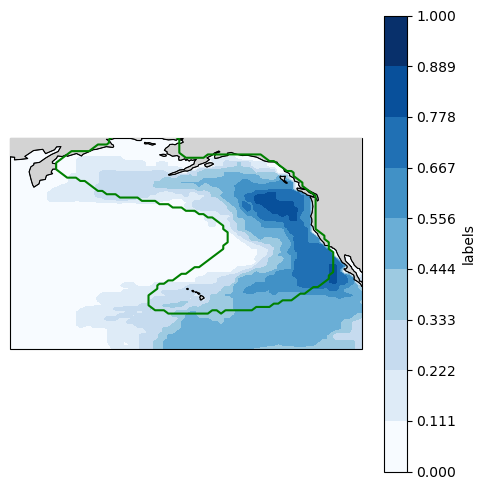

In [72]:
fosi_blob_footprint_display = fosi_blob_footprint_nan.where(fosi_blob_footprint_nan > 0.1)

fig = plt.figure(figsize=(5, 5), facecolor='white')
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
ax.set_facecolor('white')

# im = fosi_blob_footprint_display.plot.contourf(
#     ax=ax, transform=ccrs.PlateCarree(),
#     levels=np.linspace(0., 1.0, 21), cmap='Blues', add_colorbar=True,
#     extend='neither', zorder=1
# )

im = fosi_blob_footprint.plot.contourf(
    ax=ax, transform=ccrs.PlateCarree(), 
    cmap='Blues', add_colorbar=True,
    vmin=0.0, vmax=1., levels=10,
    extend='neither', zorder=1)

ax.add_feature(cfeature.LAND, facecolor='lightgrey', edgecolor='black', linewidth=0.5, zorder=10)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=11)

ax.set_extent([150, 250, 5, 65], crs=ccrs.PlateCarree())

mask_3_binary.plot.contour(
    ax=ax, transform=ccrs.PlateCarree(),
    levels=[0.5], colors='green', linewidths=1.5, zorder=20
)

plt.tight_layout()
plt.show()

In [17]:
# ============================================================
# STEP A (revised): Annual MHW counts by YEAR OF INITIAL DETECTION, avoiding double-counting
# ============================================================
annual_counts_by_method = {}

for method in base_paths:
    labels_full = da_mhwobj_labels_by_method[method]
    annual_counts_member = np.zeros((100, 2020 - 1979 + 1))

    for member_id in range(100):
        member_labels = labels_full.isel(ensemble_member=member_id)
        unique_ids = np.unique(member_labels.max(dim=('lat','lon')).data)
        unique_ids = unique_ids[~np.isnan(unique_ids)]
        unique_ids = unique_ids[unique_ids > 0]

        for object_id in unique_ids:
            first_time = member_labels.time.where((member_labels == object_id).any(dim=('lat','lon')), drop=True)[0]
            init_year = first_time.dt.year.item()
            if 1979 <= init_year <= 2020:
                yr_idx = init_year - 1979
                annual_counts_member[member_id, yr_idx] += 1

    annual_counts_by_method[method] = annual_counts_member
    print(f"{method}: done")

linear: done
quadratic: done
ensmean: done
noseas: done


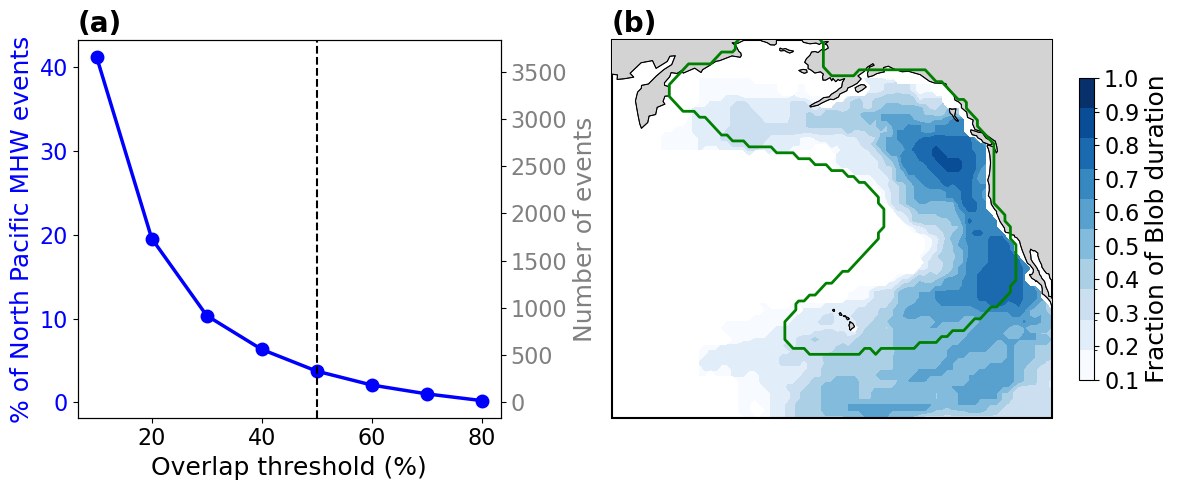

In [84]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

fig = plt.figure(figsize=(12, 5), facecolor='white')
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1.3], figure=fig)

# ============================================================
# Panel (a)
# ============================================================
ax1 = fig.add_subplot(gs[0])

pct_overlap = 100 * np.array(counts_per_threshold_by_method['linear']) / total_events_by_method['linear']
total_n_events = total_events_by_method['linear']

ax1.plot(thresholds*100, pct_overlap, color='blue', linewidth=2.5, marker='o', markersize=9)
ax1.set_xlabel('Overlap threshold (%)', fontsize=18)
ax1.set_ylabel('% of North Pacific MHW events', fontsize=18, color='blue')
ax1.tick_params(axis='y', labelcolor='blue', labelsize=16)
ax1.tick_params(axis='x', labelsize=16)
ax1.axvline(x=50, c='k', linestyle='dashed')
ax2 = ax1.twinx()
ax2.set_ylabel('Number of events', fontsize=18, color='gray')
ax2.set_ylim(ax1.get_ylim()[0] * total_n_events / 100, ax1.get_ylim()[1] * total_n_events / 100)
ax2.tick_params(axis='y', labelcolor='gray', labelsize=16)

ax1.set_title('(a)', loc='left', fontsize=20, fontweight='bold')

# ============================================================
# Panel (b)
# ============================================================
ax3 = fig.add_subplot(gs[1], projection=ccrs.PlateCarree(central_longitude=180))
ax3.set_facecolor('white')
ax3.set_aspect('auto')

im = fosi_blob_footprint_nan.plot.contourf(
    ax=ax3, transform=ccrs.PlateCarree(),
    levels=np.linspace(0.1, 1.0, 11), cmap='Blues', add_colorbar=True,
    extend='neither', zorder=1,
    cbar_kwargs={'label': 'Fraction of CESM2-FOSI Blob duration', 'shrink': 0.8, 'ticks': np.arange(0.1, 1.01, 0.1)}
)
im.colorbar.set_ticks(np.arange(0.1, 1.01, 0.1))

im.colorbar.ax.tick_params(labelsize=16)
im.colorbar.set_label('Fraction of Blob duration', fontsize=18)

ax3.add_feature(cfeature.LAND, facecolor='lightgrey', edgecolor='black', linewidth=0.5, zorder=10)
ax3.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=11)
ax3.set_extent([150, 250, 5, 65], crs=ccrs.PlateCarree())

mask_3_binary.plot.contour(
    ax=ax3, transform=ccrs.PlateCarree(),
    levels=[0.5], colors='green', linewidths=2, zorder=20
)

for spine in ax3.spines.values():
    spine.set_linewidth(1.5)
    spine.set_edgecolor('black')

ax3.set_title('(b)', loc='left', fontsize=20, fontweight='bold')

plt.tight_layout()
plt.savefig('Figure_S1.png', dpi=300, bbox_inches='tight')
plt.show()

linear: 1979-1985 mean = 2.25, 2014-2020 mean = 2.11, change = -0.15
quadratic: 1979-1985 mean = 2.27, 2014-2020 mean = 1.97, change = -0.30
ensmean: 1979-1985 mean = 2.11, 2014-2020 mean = 2.06, change = -0.05
noseas: 1979-1985 mean = 0.82, 2014-2020 mean = 2.37, change = 1.55
linear: mean annual count per member across record = 2.14, range = 1.51-2.87
quadratic: mean annual count per member across record = 2.10, range = 1.71-2.85
ensmean: mean annual count per member across record = 2.06, range = 1.78-2.32
noseas: mean annual count per member across record = 1.61, range = 0.65-2.58


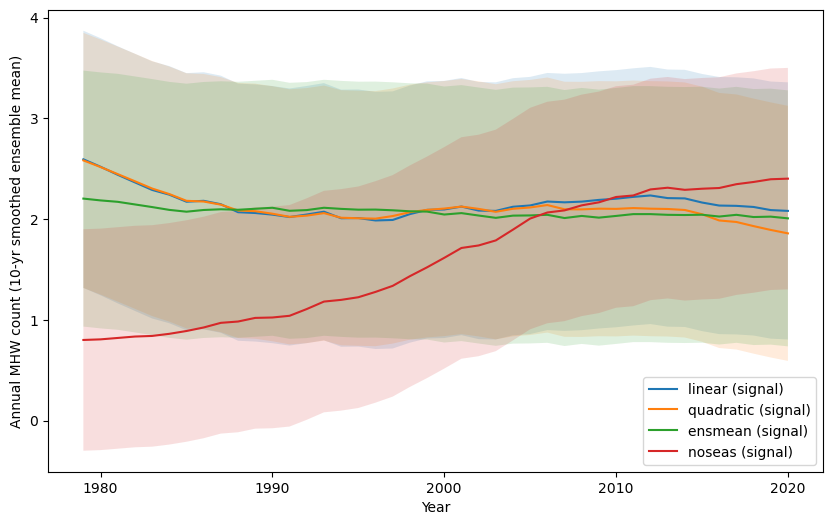

In [92]:
# --- 1. Is there even a rising trend in the raw ensemble-mean signal? ---
for method in base_paths:
    ens_mean_raw = annual_counts_by_method[method].mean(axis=0)
    print(f"{method}: 1979-1985 mean = {ens_mean_raw[:7].mean():.2f}, "
          f"2014-2020 mean = {ens_mean_raw[-7:].mean():.2f}, "
          f"change = {ens_mean_raw[-7:].mean() - ens_mean_raw[:7].mean():.2f}")

# --- 2. What's the actual scale of annual counts? (small counts = inherently noisy, weak SNR) ---
for method in base_paths:
    ens_mean_raw = annual_counts_by_method[method].mean(axis=0)
    print(f"{method}: mean annual count per member across record = {ens_mean_raw.mean():.2f}, "
          f"range = {ens_mean_raw.min():.2f}-{ens_mean_raw.max():.2f}")

# --- 3. Plot signal (S) and noise band (sigma) together to see them directly, not just the ratio ---
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,6))
for method in base_paths:
    S = ensemble_mean_signal_by_method[method]
    sigma = sigma_by_method[method]
    ax.plot(years, S, label=f'{method} (signal)')
    ax.fill_between(years, S-sigma, S+sigma, alpha=0.15)
ax.set_xlabel('Year')
ax.set_ylabel('Annual MHW count (10-yr smoothed ensemble mean)')
ax.legend()
plt.show()

In [21]:
# ============================================================
# STEP B: Ensemble mean signal, 10-year smoothed
# ============================================================
from scipy.ndimage import uniform_filter1d

ensemble_mean_signal_by_method = {}

for method in base_paths:
    ens_mean = annual_counts_by_method[method].mean(axis=0)  # average across 100 members -> (42,) time series
    smoothed = uniform_filter1d(ens_mean, size=10, mode='nearest')
    ensemble_mean_signal_by_method[method] = smoothed

years = np.arange(1979, 2021)

In [22]:
# ============================================================
# STEP C (corrected): Noise baseline from individual-member deviations, not aggregate residual
# ============================================================
sigma_by_method = {}

for method in base_paths:
    baseline_years_mask = (years >= 1979) & (years <= 1995)

    # Individual member counts during baseline period: shape (100 members, 17 years)
    member_counts_baseline = annual_counts_by_method[method][:, baseline_years_mask]

    # Deviation of each member, each year, from that year's ensemble mean
    ens_mean_baseline = member_counts_baseline.mean(axis=0)  # (17,)
    member_deviations = member_counts_baseline - ens_mean_baseline[np.newaxis, :]  # (100, 17)

    # sigma = std dev of all these member-year deviations pooled together
    sigma_by_method[method] = np.std(member_deviations)

print(sigma_by_method)

{'linear': 1.27606011291189, 'quadratic': 1.2658291865065225, 'ensmean': 1.2703102909502535, 'noseas': 1.0991627829986839}


In [23]:
# ============================================================
# STEP D: SNR and Time of Emergence
# ============================================================
ToE_by_method = {}
SNR_by_method = {}

ref_year_idx = np.where(years == 1990)[0][0]

for method in base_paths:
    S = ensemble_mean_signal_by_method[method]
    S_t0 = S[ref_year_idx]
    sigma = sigma_by_method[method]

    SNR = np.abs(S - S_t0) / sigma
    SNR_by_method[method] = SNR

    # Find first year where SNR > 2.0 for at least 5 consecutive years
    toe_year = None
    for i in range(len(SNR) - 4):
        if np.all(SNR[i:i+5] > 2.0):
            toe_year = years[i]
            break

    ToE_by_method[method] = toe_year

print(ToE_by_method)

{'linear': None, 'quadratic': None, 'ensmean': None, 'noseas': None}


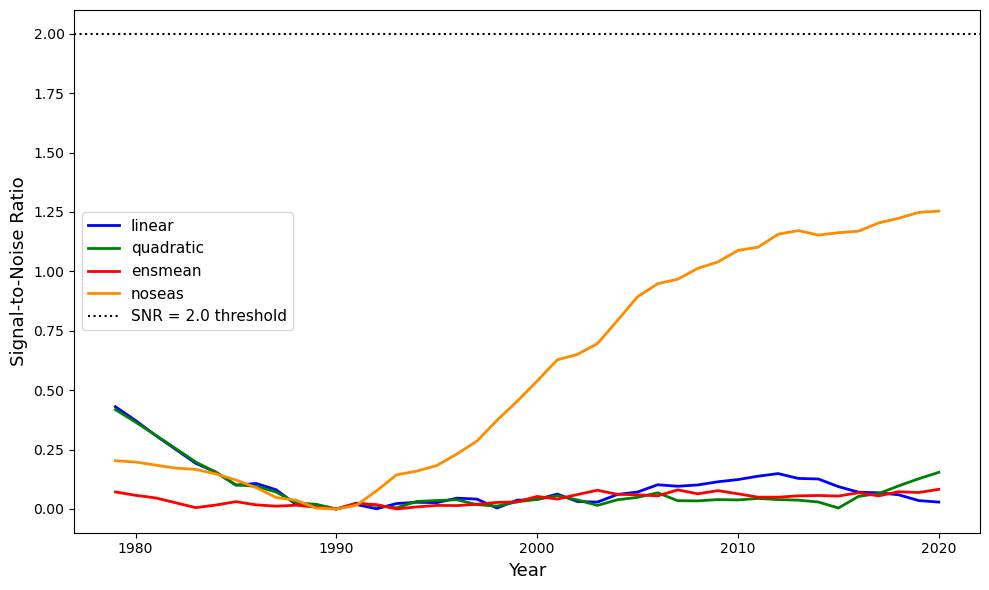

In [24]:
# ============================================================
# STEP E: Plot SNR time series across all 4 methods, with ToE marked
# ============================================================
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
colors = {'linear': 'blue', 'quadratic': 'green', 'ensmean': 'red', 'noseas': 'darkorange'}

for method in base_paths:
    ax.plot(years, SNR_by_method[method], label=method, color=colors[method], linewidth=2)
    if ToE_by_method[method] is not None:
        ax.axvline(ToE_by_method[method], color=colors[method], linestyle='--', alpha=0.5)

ax.axhline(2.0, color='black', linestyle=':', label='SNR = 2.0 threshold')
ax.set_xlabel('Year', fontsize=13)
ax.set_ylabel('Signal-to-Noise Ratio', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

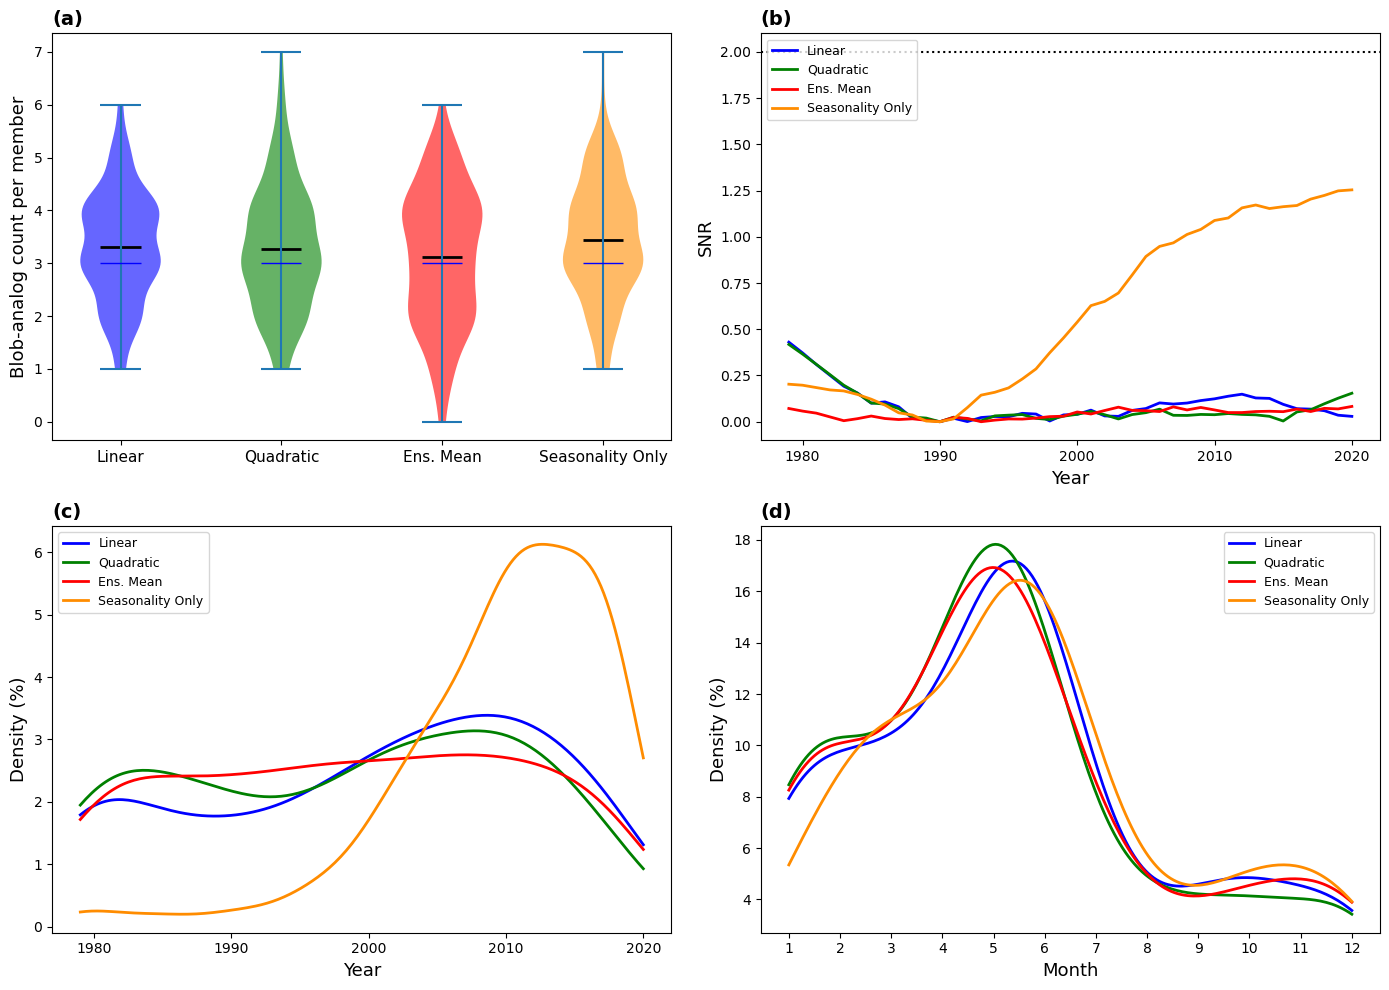

In [26]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

colors = {'linear': 'blue', 'quadratic': 'green', 'ensmean': 'red', 'noseas': 'darkorange'}
labels_display = {'linear': 'Linear', 'quadratic': 'Quadratic', 'ensmean': 'Ens. Mean', 'noseas': 'Seasonality Only'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- (a) Violin plots of Blob-analog counts per method ---
ax = axes[0, 0]
analog_counts_per_member = {
    method: [len(ids) for ids in blob_analog_ids[method]]  # list of 100 counts, one per member
    for method in base_paths
}
data_for_violin = [analog_counts_per_member[m] for m in base_paths]
parts = ax.violinplot(data_for_violin, showmeans=True, showmedians=True)

for i, method in enumerate(base_paths):
    parts['bodies'][i].set_facecolor(colors[method])
    parts['bodies'][i].set_alpha(0.6)
parts['cmeans'].set_color('black')
parts['cmeans'].set_linewidth(2)
parts['cmedians'].set_color('blue')
parts['cmedians'].set_linewidth(1)

ax.set_xticks(range(1, len(base_paths)+1))
ax.set_xticklabels([labels_display[m] for m in base_paths], fontsize=11)
ax.set_ylabel('Blob-analog count per member', fontsize=13)
ax.set_title('(a)', loc='left', fontsize=14, fontweight='bold')

# --- (b) SNR with ToE ---
ax = axes[0, 1]
for method in base_paths:
    ax.plot(years, SNR_by_method[method], label=labels_display[method], color=colors[method], linewidth=2)
    if ToE_by_method[method] is not None:
        ax.axvline(ToE_by_method[method], color=colors[method], linestyle='--', alpha=0.7)

ax.axhline(2.0, color='black', linestyle=':', linewidth=1.5)
ax.set_xlabel('Year', fontsize=13)
ax.set_ylabel('SNR', fontsize=13)
ax.legend(fontsize=9, loc='upper left')
ax.set_title('(b)', loc='left', fontsize=14, fontweight='bold')

# --- (c) KDE of Blob-analog occurrence YEAR, normalized to 100% ---
ax = axes[1, 0]
for method in base_paths:
    all_init_years = []
    labels_full = da_mhwobj_labels_by_method[method]
    for member_id in range(100):
        member_labels = labels_full.isel(ensemble_member=member_id)
        for analog_id in blob_analog_ids[method][member_id]:
            first_time = member_labels.time.where((member_labels == analog_id).any(dim=('lat','lon')), drop=True)[0]
            all_init_years.append(first_time.dt.year.item())

    if len(all_init_years) > 1:
        kde = stats.gaussian_kde(all_init_years)
        x = np.linspace(1979, 2020, 200)
        y = kde(x)
        y_pct = 100 * y / np.trapz(y, x)  # normalize area to 100
        ax.plot(x, y_pct, label=labels_display[method], color=colors[method], linewidth=2)

ax.set_xlabel('Year', fontsize=13)
ax.set_ylabel('Density (%)', fontsize=13)
ax.legend(fontsize=9)
ax.set_title('(c)', loc='left', fontsize=14, fontweight='bold')

# --- (d) KDE of Blob-analog detection MONTH ---
ax = axes[1, 1]
for method in base_paths:
    all_init_months = []
    labels_full = da_mhwobj_labels_by_method[method]
    for member_id in range(100):
        member_labels = labels_full.isel(ensemble_member=member_id)
        for analog_id in blob_analog_ids[method][member_id]:
            first_time = member_labels.time.where((member_labels == analog_id).any(dim=('lat','lon')), drop=True)[0]
            all_init_months.append(first_time.dt.month.item())

    if len(all_init_months) > 1:
        kde = stats.gaussian_kde(all_init_months)
        x = np.linspace(1, 12, 200)
        y = kde(x)
        y_pct = 100 * y / np.trapz(y, x)
        ax.plot(x, y_pct, label=labels_display[method], color=colors[method], linewidth=2)

ax.set_xlabel('Month', fontsize=13)
ax.set_ylabel('Density (%)', fontsize=13)
ax.set_xticks(range(1,13))
ax.legend(fontsize=9)
ax.set_title('(d)', loc='left', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('Figure4.png', dpi=300)
plt.show()

In [85]:
import numpy as np

# ============================================================
# Panel (a) - Blob-analog count statistics per method
# ============================================================
print("=== Panel (a): Blob-analog counts per method ===")
for method in base_paths:
    counts = np.array(analog_counts_per_member[method])
    total = counts.sum()
    print(f"{method}: total={total}, mean/member={counts.mean():.2f}, "
          f"median={np.median(counts):.1f}, min={counts.min()}, max={counts.max()}")

=== Panel (a): Blob-analog counts per method ===
linear: total=331, mean/member=3.31, median=3.0, min=1, max=6
quadratic: total=327, mean/member=3.27, median=3.0, min=1, max=7
ensmean: total=312, mean/member=3.12, median=3.0, min=0, max=6
noseas: total=343, mean/member=3.43, median=3.0, min=1, max=7


In [90]:
# ============================================================
# Panel (b) - SNR/ToE statistics per method
# ============================================================
print("\n=== Panel (b): Time of Emergence per method ===")
for method in base_paths:
    toe = ToE_by_method[method]
    sigma = sigma_by_method[method]
    max_snr = np.max(SNR_by_method[method])
    max_snr_year = years[np.argmax(SNR_by_method[method])]
    print(f"{method}: ToE={toe}, noise baseline (sigma)={sigma:.3f}, "
          f"max SNR={max_snr:.2f} (in {max_snr_year})")

toe_values = [v for v in ToE_by_method.values() if v is not None]
if toe_values:
    print(f"ToE range across methods: {min(toe_values)}-{max(toe_values)} ({max(toe_values)-min(toe_values)} year spread)")
else:
    print("No method reaches ToE within the 1979-2020 record (SNR never sustains >2.0 for 5 consecutive years).")


=== Panel (b): Time of Emergence per method ===
linear: ToE=None, noise baseline (sigma)=1.276, max SNR=0.43 (in 1979)
quadratic: ToE=None, noise baseline (sigma)=1.266, max SNR=0.42 (in 1979)
ensmean: ToE=None, noise baseline (sigma)=1.270, max SNR=0.08 (in 2020)
noseas: ToE=None, noise baseline (sigma)=1.099, max SNR=1.25 (in 2020)
No method reaches ToE within the 1979-2020 record (SNR never sustains >2.0 for 5 consecutive years).


In [87]:
# ============================================================
# Panel (c) - Year distribution: peak year, spread, any trend
# ============================================================
print("\n=== Panel (c): Blob-analog initial-detection year distribution ===")
for method in base_paths:
    all_init_years = []
    labels_full = da_mhwobj_labels_by_method[method]
    for member_id in range(100):
        member_labels = labels_full.isel(ensemble_member=member_id)
        for analog_id in blob_analog_ids[method][member_id]:
            first_time = member_labels.time.where((member_labels == analog_id).any(dim=('lat','lon')), drop=True)[0]
            all_init_years.append(first_time.dt.year.item())

    all_init_years = np.array(all_init_years)
    # Fraction of analogs occurring in second half of record (2000-2020) vs first half (1979-1999)
    frac_early = np.mean(all_init_years < 2000) * 100
    frac_late = np.mean(all_init_years >= 2000) * 100

    print(f"{method}: mean year={all_init_years.mean():.1f}, median={np.median(all_init_years):.0f}, "
          f"% before 2000={frac_early:.1f}%, % 2000 onward={frac_late:.1f}%")


=== Panel (c): Blob-analog initial-detection year distribution ===
linear: mean year=2000.2, median=2002, % before 2000=42.3%, % 2000 onward=57.7%
quadratic: mean year=1998.5, median=2000, % before 2000=48.0%, % 2000 onward=52.0%
ensmean: mean year=1998.9, median=2000, % before 2000=50.0%, % 2000 onward=50.0%
noseas: mean year=2009.8, median=2011, % before 2000=7.6%, % 2000 onward=92.4%


In [88]:
# ============================================================
# Panel (d) - Month distribution: peak month, seasonal concentration
# ============================================================
print("\n=== Panel (d): Blob-analog initial-detection month distribution ===")
from collections import Counter

for method in base_paths:
    all_init_months = []
    labels_full = da_mhwobj_labels_by_method[method]
    for member_id in range(100):
        member_labels = labels_full.isel(ensemble_member=member_id)
        for analog_id in blob_analog_ids[method][member_id]:
            first_time = member_labels.time.where((member_labels == analog_id).any(dim=('lat','lon')), drop=True)[0]
            all_init_months.append(first_time.dt.month.item())

    month_counts = Counter(all_init_months)
    peak_month = month_counts.most_common(1)[0]
    month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

    # % occurring in winter (DJF) vs summer (JJA), as a quick seasonal-concentration check
    winter_frac = np.mean(np.isin(all_init_months, [12,1,2])) * 100
    summer_frac = np.mean(np.isin(all_init_months, [6,7,8])) * 100

    print(f"{method}: peak month={month_names[peak_month[0]-1]} ({peak_month[1]} events, "
          f"{100*peak_month[1]/len(all_init_months):.1f}%), "
          f"% DJF={winter_frac:.1f}%, % JJA={summer_frac:.1f}%")


=== Panel (d): Blob-analog initial-detection month distribution ===
linear: peak month=May (62 events, 18.7%), % DJF=24.2%, % JJA=26.3%
quadratic: peak month=May (71 events, 21.7%), % DJF=26.3%, % JJA=22.3%
ensmean: peak month=May (63 events, 20.2%), % DJF=26.3%, % JJA=22.1%
noseas: peak month=Jun (63 events, 18.4%), % DJF=19.0%, % JJA=30.0%


In [89]:
# ============================================================
# Cross-check: where does the FOSI Blob (initial detection May 2014) fall relative to each distribution?
# ============================================================
print("\n=== FOSI Blob context ===")
print("FOSI Blob initial detection: May 2014")
for method in base_paths:
    all_init_years = []
    labels_full = da_mhwobj_labels_by_method[method]
    for member_id in range(100):
        member_labels = labels_full.isel(ensemble_member=member_id)
        for analog_id in blob_analog_ids[method][member_id]:
            first_time = member_labels.time.where((member_labels == analog_id).any(dim=('lat','lon')), drop=True)[0]
            all_init_years.append(first_time.dt.year.item())
    pct_below_2014 = np.mean(np.array(all_init_years) <= 2014) * 100
    print(f"{method}: {pct_below_2014:.1f}% of analogs initiated in or before 2014")


=== FOSI Blob context ===
FOSI Blob initial detection: May 2014
linear: 87.3% of analogs initiated in or before 2014
quadratic: 91.4% of analogs initiated in or before 2014
ensmean: 87.8% of analogs initiated in or before 2014
noseas: 69.1% of analogs initiated in or before 2014


In [93]:
# ============================================================
# Annual MHW counts by DOUBLE-COUNTING - an event counted in every year it's active
# ============================================================
annual_counts_by_method_doublecount = {}

for method in base_paths:
    labels_full = da_mhwobj_labels_by_method[method]
    annual_counts_member = np.zeros((100, 2020 - 1979 + 1))

    for member_id in range(100):
        member_labels = labels_full.isel(ensemble_member=member_id)
        unique_ids = np.unique(member_labels.max(dim=('lat','lon')).data)
        unique_ids = unique_ids[~np.isnan(unique_ids)]
        unique_ids = unique_ids[unique_ids > 0]

        for object_id in unique_ids:
            times_present = member_labels.time.where((member_labels == object_id).any(dim=('lat','lon')), drop=True)
            years_present = np.unique(times_present.dt.year.values)
            for yr in years_present:
                if 1979 <= yr <= 2020:
                    yr_idx = yr - 1979
                    annual_counts_member[member_id, yr_idx] += 1  # counted once per year it's active in, even if multiple years

    annual_counts_by_method_doublecount[method] = annual_counts_member
    print(f"{method}: done (double-count convention)")

linear: done (double-count convention)
quadratic: done (double-count convention)
ensmean: done (double-count convention)
noseas: done (double-count convention)


In [94]:
# ============================================================
# STEP B: Ensemble mean signal, 10-year smoothed
# ============================================================
from scipy.ndimage import uniform_filter1d
import numpy as np

years = np.arange(1979, 2021)

ensemble_mean_signal_by_method = {}

for method in base_paths:
    ens_mean = annual_counts_by_method_doublecount[method].mean(axis=0)  # average across 100 members
    smoothed = uniform_filter1d(ens_mean, size=10, mode='nearest')
    ensemble_mean_signal_by_method[method] = smoothed

print("Signal computed for:", list(ensemble_mean_signal_by_method.keys()))

Signal computed for: ['linear', 'quadratic', 'ensmean', 'noseas']


In [95]:
# ============================================================
# STEP C: Noise baseline - std dev of INDIVIDUAL MEMBER deviations from ensemble mean, 1979-1995
# ============================================================
sigma_by_method = {}

for method in base_paths:
    baseline_years_mask = (years >= 1979) & (years <= 1995)

    member_counts_baseline = annual_counts_by_method_doublecount[method][:, baseline_years_mask]  # (100, 17)
    ens_mean_baseline = member_counts_baseline.mean(axis=0)  # (17,)
    member_deviations = member_counts_baseline - ens_mean_baseline[np.newaxis, :]  # (100, 17)

    sigma_by_method[method] = np.std(member_deviations)

print(sigma_by_method)

{'linear': 1.2877317038795273, 'quadratic': 1.2567816039392046, 'ensmean': 1.2780591903811211, 'noseas': 1.1172971588509792}


In [96]:
# ============================================================
# STEP D: SNR and Time of Emergence
# ============================================================
ToE_by_method = {}
SNR_by_method = {}

ref_year_idx = np.where(years == 1990)[0][0]

for method in base_paths:
    S = ensemble_mean_signal_by_method[method]
    S_t0 = S[ref_year_idx]
    sigma = sigma_by_method[method]

    SNR = np.abs(S - S_t0) / sigma
    SNR_by_method[method] = SNR

    toe_year = None
    for i in range(len(SNR) - 4):
        if np.all(SNR[i:i+5] > 2.0):
            toe_year = years[i]
            break

    ToE_by_method[method] = toe_year

print(ToE_by_method)

{'linear': None, 'quadratic': None, 'ensmean': None, 'noseas': None}


In [97]:
# ============================================================
# Quick sanity checks before trusting the result
# ============================================================
for method in base_paths:
    S = ensemble_mean_signal_by_method[method]
    print(f"{method}: signal 1979-85 mean={S[:7].mean():.2f}, "
          f"2014-2020 mean={S[-7:].mean():.2f}, "
          f"max SNR={SNR_by_method[method].max():.2f}, "
          f"ToE={ToE_by_method[method]}")

linear: signal 1979-85 mean=2.59, 2014-2020 mean=2.46, max SNR=0.35, ToE=None
quadratic: signal 1979-85 mean=2.62, 2014-2020 mean=2.25, max SNR=0.31, ToE=None
ensmean: signal 1979-85 mean=2.34, 2014-2020 mean=2.36, max SNR=0.08, ToE=None
noseas: signal 1979-85 mean=0.86, 2014-2020 mean=3.05, max SNR=1.90, ToE=None


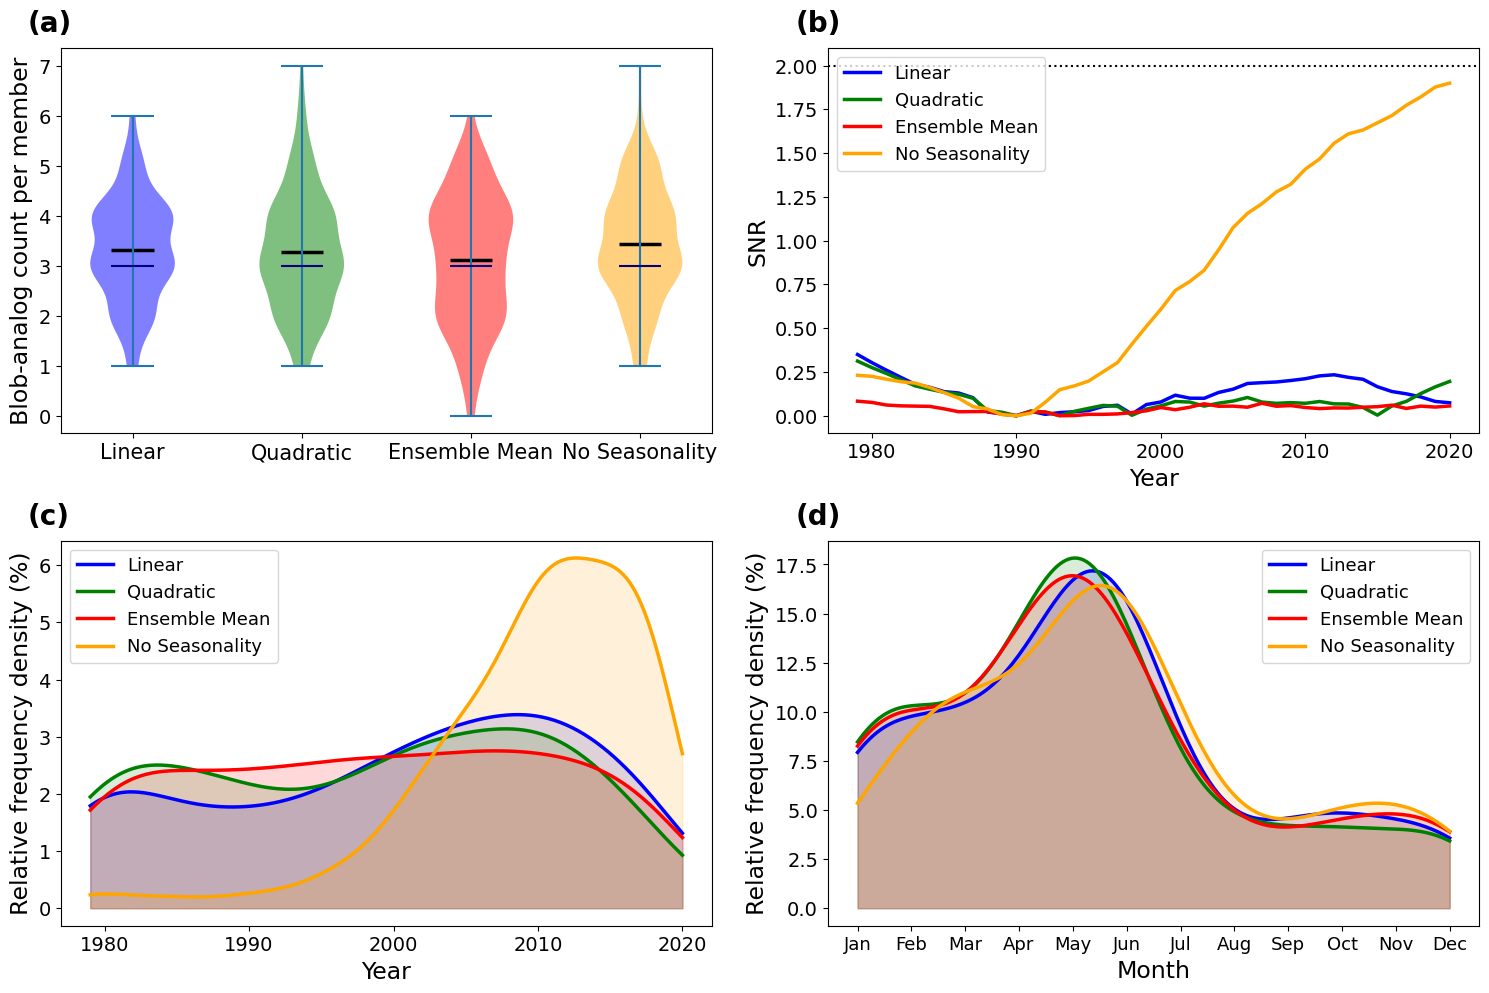

In [102]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

colors = {'linear': 'blue', 'quadratic': 'green', 'ensmean': 'red', 'noseas': 'orange'}
labels_display = {'linear': 'Linear', 'quadratic': 'Quadratic', 'ensmean': 'Ensemble Mean', 'noseas': 'No Seasonality'}

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# ============================================================
# (a) Violin plots
# ============================================================
ax = axes[0, 0]
analog_counts_per_member = {
    method: [len(ids) for ids in blob_analog_ids[method]]
    for method in base_paths
}
data_for_violin = [analog_counts_per_member[m] for m in base_paths]
parts = ax.violinplot(data_for_violin, showmeans=True, showmedians=True, showextrema=True)

for i, method in enumerate(base_paths):
    parts['bodies'][i].set_facecolor(colors[method])
    parts['bodies'][i].set_alpha(0.5)
parts['cmeans'].set_color('black')
parts['cmeans'].set_linewidth(2.5)
parts['cmedians'].set_color('navy')
parts['cmedians'].set_linewidth(1.5)

ax.set_xticks(range(1, len(base_paths)+1))
ax.set_xticklabels([labels_display[m] for m in base_paths], fontsize=15)
ax.set_ylabel('Blob-analog count per member', fontsize=17)
ax.tick_params(axis='y', labelsize=14)
ax.text(-0.05, 1.10, '(a)', transform=ax.transAxes, fontsize=20, fontweight='bold', va='top')

# ============================================================
# (b) SNR - no ToE lines since none reach threshold
# ============================================================
ax = axes[0, 1]
for method in base_paths:
    ax.plot(years, SNR_by_method[method], label=labels_display[method], color=colors[method], linewidth=2.5)

ax.axhline(2.0, color='black', linestyle=':', linewidth=1.5)
ax.set_xlabel('Year', fontsize=17)
ax.set_ylabel('SNR', fontsize=17)
ax.tick_params(labelsize=14)
ax.legend(fontsize=13, loc='upper left')
ax.text(-0.05, 1.10, '(b)', transform=ax.transAxes, fontsize=20, fontweight='bold', va='top')

# ============================================================
# (c) KDE of Blob-analog initial-detection YEAR, filled
# ============================================================
ax = axes[1, 0]
for method in base_paths:
    all_init_years = []
    labels_full = da_mhwobj_labels_by_method[method]
    for member_id in range(100):
        member_labels = labels_full.isel(ensemble_member=member_id)
        for analog_id in blob_analog_ids[method][member_id]:
            first_time = member_labels.time.where((member_labels == analog_id).any(dim=('lat','lon')), drop=True)[0]
            all_init_years.append(first_time.dt.year.item())

    if len(all_init_years) > 1:
        kde = stats.gaussian_kde(all_init_years)
        x = np.linspace(1979, 2020, 200)
        y = kde(x)
        y_pct = 100 * y / np.trapz(y, x)
        ax.plot(x, y_pct, label=labels_display[method], color=colors[method], linewidth=2.5)
        ax.fill_between(x, y_pct, alpha=0.15, color=colors[method])

ax.set_xlabel('Year', fontsize=17)
ax.set_ylabel('Relative frequency density (%)', fontsize=17)
ax.tick_params(labelsize=14)
ax.legend(fontsize=13)
ax.text(-0.05, 1.10, '(c)', transform=ax.transAxes, fontsize=20, fontweight='bold', va='top')

# ============================================================
# (d) KDE of Blob-analog initial-detection MONTH, filled
# ============================================================
ax = axes[1, 1]
for method in base_paths:
    all_init_months = []
    labels_full = da_mhwobj_labels_by_method[method]
    for member_id in range(100):
        member_labels = labels_full.isel(ensemble_member=member_id)
        for analog_id in blob_analog_ids[method][member_id]:
            first_time = member_labels.time.where((member_labels == analog_id).any(dim=('lat','lon')), drop=True)[0]
            all_init_months.append(first_time.dt.month.item())

    if len(all_init_months) > 1:
        kde = stats.gaussian_kde(all_init_months)
        x = np.linspace(1, 12, 200)
        y = kde(x)
        y_pct = 100 * y / np.trapz(y, x)
        ax.plot(x, y_pct, label=labels_display[method], color=colors[method], linewidth=2.5)
        ax.fill_between(x, y_pct, alpha=0.15, color=colors[method])

ax.set_xlabel('Month', fontsize=17)
ax.set_ylabel('Relative frequency density (%)', fontsize=17)
ax.set_xticks(range(1,13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], fontsize=13)
ax.tick_params(axis='y', labelsize=14)
ax.legend(fontsize=13)
ax.text(-0.05, 1.10, '(d)', transform=ax.transAxes, fontsize=20, fontweight='bold', va='top')

plt.tight_layout()
# plt.savefig('Figure4.png', dpi=300, bbox_inches='tight')
plt.show()

In [103]:
# ============================================================
# Base-rate check: what fraction of the record itself falls "on or before 2014"?
# ============================================================
total_years = 2020 - 1979 + 1  # 42
years_up_to_2014 = 2014 - 1979 + 1  # 36
baseline_fraction = 100 * years_up_to_2014 / total_years

print(f"If analogs were uniformly distributed across 1979-2020, "
      f"we'd expect {baseline_fraction:.1f}% to fall in/before 2014 by chance alone.")

If analogs were uniformly distributed across 1979-2020, we'd expect 85.7% to fall in/before 2014 by chance alone.


In [104]:
actual_pcts = {'linear': 87.3, 'quadratic': 91.4, 'ensmean': 87.8, 'noseas': 69.1}

for method, pct in actual_pcts.items():
    diff = pct - baseline_fraction
    print(f"{method}: {pct}% actual vs {baseline_fraction:.1f}% baseline -> {diff:+.1f} percentage points")

linear: 87.3% actual vs 85.7% baseline -> +1.6 percentage points
quadratic: 91.4% actual vs 85.7% baseline -> +5.7 percentage points
ensmean: 87.8% actual vs 85.7% baseline -> +2.1 percentage points
noseas: 69.1% actual vs 85.7% baseline -> -16.6 percentage points


In [105]:
# ============================================================
# Isolate summer-initiated (JJA) vs spring-initiated (MAM) Blob-analogs
# ============================================================
summer_analogs = {method: [] for method in base_paths}
spring_analogs = {method: [] for method in base_paths}

for method in base_paths:
    labels_full = da_mhwobj_labels_by_method[method]
    for member_id in range(100):
        member_labels = labels_full.isel(ensemble_member=member_id)
        for analog_id in blob_analog_ids[method][member_id]:
            first_time = member_labels.time.where((member_labels == analog_id).any(dim=('lat','lon')), drop=True)[0]
            month = first_time.dt.month.item()
            if month in [6,7,8]:
                summer_analogs[method].append((member_id, analog_id, first_time))
            elif month in [3,4,5]:
                spring_analogs[method].append((member_id, analog_id, first_time))

for method in base_paths:
    print(f"{method}: {len(summer_analogs[method])} summer-initiated, {len(spring_analogs[method])} spring-initiated")

linear: 87 summer-initiated, 122 spring-initiated
quadratic: 73 summer-initiated, 134 spring-initiated
ensmean: 69 summer-initiated, 124 spring-initiated
noseas: 103 summer-initiated, 127 spring-initiated


In [108]:
# Rebuild cell_area_da for the CESM2-LENS grid
R = 6371.0  # km

# Use the grid from whichever labels dataset you're working with
grid_ref = da_mhwobj_labels_by_method['linear']

dlat = np.deg2rad(np.mean(np.diff(grid_ref.lat.values)))
dlon = np.deg2rad(np.mean(np.diff(grid_ref.lon.values)))
cell_area = (R**2) * dlat * dlon * np.cos(np.deg2rad(grid_ref.lat))
cell_area_da = xr.DataArray(cell_area.values, coords={'lat': grid_ref.lat}, dims='lat')

print(f"Equatorial check: {float(cell_area_da.sel(lat=grid_ref.lat.values[len(grid_ref.lat)//2])):.1f} km²")

Equatorial check: 11881.4 km²


In [113]:
def get_analog_stats(method, analog_list, ssta_dataset, mld_field, cell_area_da, ssta_varname='ssta'):
    stats_list = []
    labels_full = da_mhwobj_labels_by_method[method]
    for member_id, analog_id, first_time in analog_list:
        member_labels = labels_full.isel(ensemble_member=member_id)
        mask = (member_labels == analog_id)
        times_present = member_labels.time.where(mask.any(dim=('lat','lon')), drop=True)

        mask_trimmed = mask.sel(time=times_present)
        ssta_da = ssta_dataset[ssta_varname]  # extract the actual DataArray from the Dataset
        ssta_masked = ssta_da.isel(ensemble_member=member_id).sel(time=times_present).where(mask_trimmed)
        extent_ts = (mask_trimmed.astype(int) * cell_area_da).sum(dim=('lat','lon'))

        stats_list.append({
            'duration': len(times_present),
            'intensity_max': float(ssta_masked.max()),
            'extent_max': float(extent_ts.max()),
        })
    return stats_list

summer_stats = get_analog_stats('linear', summer_analogs['linear'], ssta_notrend_by_method['linear'], None, cell_area_da, ssta_varname='__xarray_dataarray_variable__')  # adjust varname
spring_stats = get_analog_stats('linear', spring_analogs['linear'], ssta_notrend_by_method['linear'], None, cell_area_da, ssta_varname='__xarray_dataarray_variable__')
import numpy as np
for label, stats_list in [('Summer', summer_stats), ('Spring', spring_stats)]:
    durations = [s['duration'] for s in stats_list]
    intensities = [s['intensity_max'] for s in stats_list]
    extents = [s['extent_max'] for s in stats_list]
    print(f"{label} (n={len(stats_list)}): "
          f"duration={np.mean(durations):.1f}±{np.std(durations):.1f} months, "
          f"max SSTa={np.mean(intensities):.2f}±{np.std(intensities):.2f}°C, "
          f"max extent={np.mean(extents):,.0f}±{np.std(extents):,.0f} km²")

Summer (n=87): duration=9.2±6.3 months, max SSTa=3.44±1.19°C, max extent=16,287,572±4,834,396 km²
Spring (n=122): duration=13.6±7.3 months, max SSTa=3.63±1.24°C, max extent=18,584,924±4,437,904 km²


In [107]:
# ============================================================
# Spatial pattern check: do summer analogs show a different centroid/location
# than spring analogs (e.g., more Gulf-of-Alaska concentrated, like Blob 2.0)?
# ============================================================
def get_centroid(method, analog_id, member_id):
    member_labels = da_mhwobj_labels_by_method[method].isel(ensemble_member=member_id)
    mask = (member_labels == analog_id).any(dim='time')
    lat2d, lon2d = xr.broadcast(mask.lat, mask.lon)
    w = mask.where(mask)
    centroid_lat = float((lat2d*w).sum()/w.sum())
    centroid_lon = float((lon2d*w).sum()/w.sum())
    return centroid_lat, centroid_lon

summer_centroids = [get_centroid('linear', aid, mid) for mid, aid, t in summer_analogs['linear']]
spring_centroids = [get_centroid('linear', aid, mid) for mid, aid, t in spring_analogs['linear']]

print("Summer centroid (mean lat, lon):", np.mean([c[0] for c in summer_centroids]), np.mean([c[1] for c in summer_centroids]))
print("Spring centroid (mean lat, lon):", np.mean([c[0] for c in spring_centroids]), np.mean([c[1] for c in spring_centroids]))

Summer centroid (mean lat, lon): 36.12702001352727 206.86588671993903
Spring centroid (mean lat, lon): 33.60679398565813 206.39333656118177


In [114]:
def get_onset_centroid(method, analog_id, member_id):
    member_labels = da_mhwobj_labels_by_method[method].isel(ensemble_member=member_id)
    mask_all = (member_labels == analog_id)
    first_time = member_labels.time.where(mask_all.any(dim=('lat','lon')), drop=True)[0]
    mask_onset = mask_all.sel(time=first_time)

    lat2d, lon2d = xr.broadcast(mask_onset.lat, mask_onset.lon)
    w = mask_onset.where(mask_onset)
    centroid_lat = float((lat2d*w).sum()/w.sum())
    centroid_lon = float((lon2d*w).sum()/w.sum())
    return centroid_lat, centroid_lon

summer_onset_centroids = [get_onset_centroid('linear', aid, mid) for mid, aid, t in summer_analogs['linear']]
spring_onset_centroids = [get_onset_centroid('linear', aid, mid) for mid, aid, t in spring_analogs['linear']]

print("Summer ONSET centroid:", np.mean([c[0] for c in summer_onset_centroids]), np.mean([c[1] for c in summer_onset_centroids]))
print("Spring ONSET centroid:", np.mean([c[0] for c in spring_onset_centroids]), np.mean([c[1] for c in spring_onset_centroids]))

Summer ONSET centroid: 44.0207213126025 203.41546269580172
Spring ONSET centroid: 35.66817443174381 209.65732377298735


In [115]:
# ============================================================
# Winter-initiated (DJF) Blob-analogs, as a third category
# ============================================================
winter_analogs = {method: [] for method in base_paths}

for method in base_paths:
    labels_full = da_mhwobj_labels_by_method[method]
    for member_id in range(100):
        member_labels = labels_full.isel(ensemble_member=member_id)
        for analog_id in blob_analog_ids[method][member_id]:
            first_time = member_labels.time.where((member_labels == analog_id).any(dim=('lat','lon')), drop=True)[0]
            month = first_time.dt.month.item()
            if month in [12,1,2]:
                winter_analogs[method].append((member_id, analog_id, first_time))

for method in base_paths:
    print(f"{method}: {len(winter_analogs[method])} winter-initiated")

linear: 80 winter-initiated
quadratic: 86 winter-initiated
ensmean: 82 winter-initiated
noseas: 65 winter-initiated


In [117]:
# --- Characteristics and onset centroid for winter analogs (linear method) ---
winter_stats = get_analog_stats('linear', winter_analogs['linear'], ssta_notrend_by_method['linear'], None, cell_area_da, ssta_varname='__xarray_dataarray_variable__')

durations = [s['duration'] for s in winter_stats]
intensities = [s['intensity_max'] for s in winter_stats]
extents = [s['extent_max'] for s in winter_stats]
print(f"Winter (n={len(winter_stats)}): "
      f"duration={np.mean(durations):.1f}±{np.std(durations):.1f} months, "
      f"max SSTa={np.mean(intensities):.2f}±{np.std(intensities):.2f}°C, "
      f"max extent={np.mean(extents):,.0f}±{np.std(extents):,.0f} km²")

winter_onset_centroids = [get_onset_centroid('linear', aid, mid) for mid, aid, t in winter_analogs['linear']]
print("Winter ONSET centroid:", np.mean([c[0] for c in winter_onset_centroids]), np.mean([c[1] for c in winter_onset_centroids]))

Winter (n=80): duration=16.4±7.3 months, max SSTa=4.26±1.77°C, max extent=20,580,972±5,097,443 km²
Winter ONSET centroid: 31.191181286160344 206.71990160187835


In [118]:
# ============================================================
# STEP 1: Statistical significance testing across the three seasonal groups
# ============================================================
from scipy import stats
import numpy as np

# Recompute stats lists if not already in memory (winter_stats, spring_stats, summer_stats from earlier)
winter_durations = [s['duration'] for s in winter_stats]
spring_durations = [s['duration'] for s in spring_stats]
summer_durations = [s['duration'] for s in summer_stats]

winter_intensities = [s['intensity_max'] for s in winter_stats]
spring_intensities = [s['intensity_max'] for s in spring_stats]
summer_intensities = [s['intensity_max'] for s in summer_stats]

winter_extents = [s['extent_max'] for s in winter_stats]
spring_extents = [s['extent_max'] for s in spring_stats]
summer_extents = [s['extent_max'] for s in summer_stats]

# One-way ANOVA across all three groups, for each metric
print("=== One-way ANOVA (winter vs spring vs summer) ===")
for name, (w, sp, su) in [('Duration', (winter_durations, spring_durations, summer_durations)),
                            ('Intensity', (winter_intensities, spring_intensities, summer_intensities)),
                            ('Extent', (winter_extents, spring_extents, summer_extents))]:
    f_stat, p_val = stats.f_oneway(w, sp, su)
    print(f"{name}: F={f_stat:.2f}, p={p_val:.2e}")

=== One-way ANOVA (winter vs spring vs summer) ===
Duration: F=22.22, p=1.07e-09
Intensity: F=7.73, p=5.38e-04
Extent: F=16.95, p=1.10e-07


In [119]:
# ============================================================
# STEP 2: Pairwise post-hoc tests (Tukey HSD), since ANOVA only tells you "some group differs"
# ============================================================
from statsmodels.stats.multicomp import pairwise_tukeyhsd

for name, (w, sp, su) in [('Duration', (winter_durations, spring_durations, summer_durations)),
                            ('Intensity', (winter_intensities, spring_intensities, summer_intensities)),
                            ('Extent', (winter_extents, spring_extents, summer_extents))]:
    values = w + sp + su
    groups = ['Winter']*len(w) + ['Spring']*len(sp) + ['Summer']*len(su)
    print(f"\n=== {name} - Tukey HSD ===")
    result = pairwise_tukeyhsd(values, groups, alpha=0.05)
    print(result)


=== Duration - Tukey HSD ===
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
Spring Summer  -4.3357   0.0 -6.6615 -2.0099   True
Spring Winter   2.8344 0.015    0.45  5.2189   True
Summer Winter   7.1701   0.0  4.6027  9.7375   True
---------------------------------------------------

=== Intensity - Tukey HSD ===
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
Spring Summer  -0.1889 0.6029 -0.6524 0.2747  False
Spring Winter   0.6243 0.0061   0.149 1.0995   True
Summer Winter   0.8131 0.0006  0.3014 1.3248   True
---------------------------------------------------

=== Extent - Tukey HSD ===
        Multiple Comparison of Means - Tukey HSD, FWER=0.05         
group1 group2    meandiff   p-adj      lower        upper     reject
---------------------------------------------

In [120]:
from itertools import combinations

def pairwise_ttests(groups_dict, name):
    print(f"\n=== {name} - pairwise t-tests (Bonferroni-corrected) ===")
    pairs = list(combinations(groups_dict.keys(), 2))
    alpha_corrected = 0.05 / len(pairs)
    for g1, g2 in pairs:
        t_stat, p_val = stats.ttest_ind(groups_dict[g1], groups_dict[g2])
        sig = "significant" if p_val < alpha_corrected else "not significant"
        print(f"{g1} vs {g2}: t={t_stat:.2f}, p={p_val:.4f}, ({sig} at α={alpha_corrected:.4f})")

pairwise_ttests({'Winter': winter_durations, 'Spring': spring_durations, 'Summer': summer_durations}, 'Duration')
pairwise_ttests({'Winter': winter_intensities, 'Spring': spring_intensities, 'Summer': summer_intensities}, 'Intensity')
pairwise_ttests({'Winter': winter_extents, 'Spring': spring_extents, 'Summer': summer_extents}, 'Extent')


=== Duration - pairwise t-tests (Bonferroni-corrected) ===
Winter vs Spring: t=2.69, p=0.0078, (significant at α=0.0167)
Winter vs Summer: t=6.79, p=0.0000, (significant at α=0.0167)
Spring vs Summer: t=4.47, p=0.0000, (significant at α=0.0167)

=== Intensity - pairwise t-tests (Bonferroni-corrected) ===
Winter vs Spring: t=2.93, p=0.0038, (significant at α=0.0167)
Winter vs Summer: t=3.49, p=0.0006, (significant at α=0.0167)
Spring vs Summer: t=1.10, p=0.2743, (not significant at α=0.0167)

=== Extent - pairwise t-tests (Bonferroni-corrected) ===
Winter vs Spring: t=2.93, p=0.0038, (significant at α=0.0167)
Winter vs Summer: t=5.55, p=0.0000, (significant at α=0.0167)
Spring vs Summer: t=3.54, p=0.0005, (significant at α=0.0167)


/glade/derecho/scratch/cassiacai/tmp/ipykernel_24576/188277362.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=season_order, patch_artist=True, widths=0.6)
/glade/derecho/scratch/cassiacai/tmp/ipykernel_24576/188277362.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=season_order, patch_artist=True, widths=0.6)
/glade/derecho/scratch/cassiacai/tmp/ipykernel_24576/188277362.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=season_order, patch_artist=True, widths=0.6)


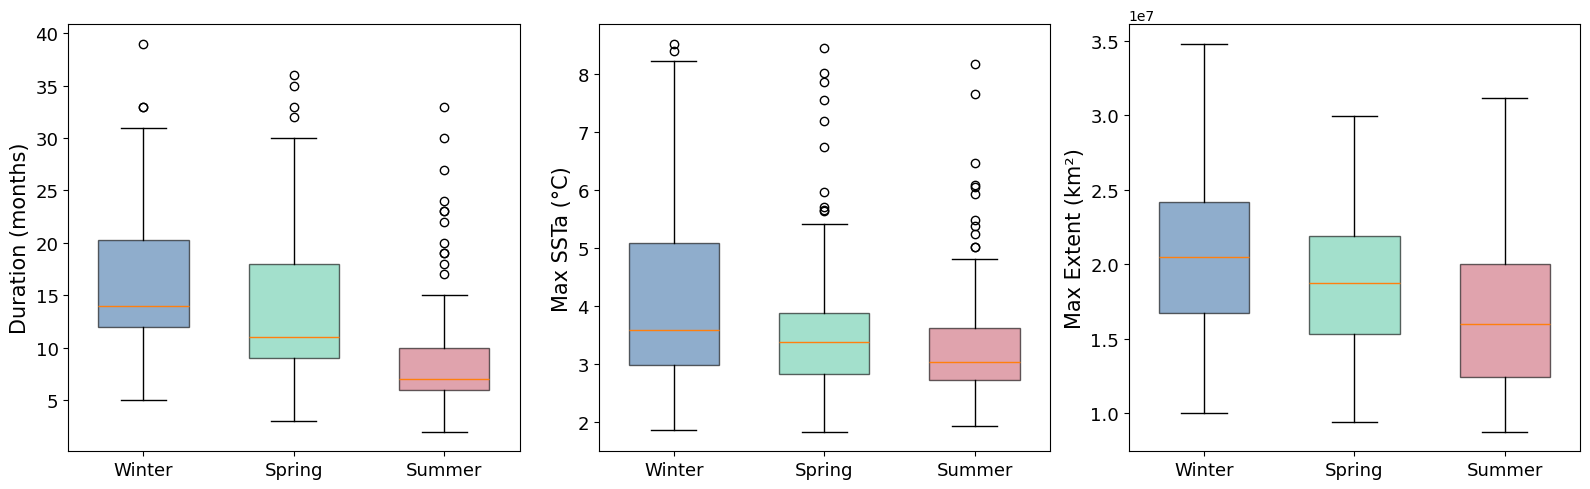

In [121]:
# ============================================================
# STEP 3: Figure - boxplots/violins of duration, intensity, extent by season, with significance annotations
# ============================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
season_colors = {'Winter': '#4477AA', 'Spring': '#66CCAA', 'Summer': '#CC6677'}
season_order = ['Winter', 'Spring', 'Summer']

metrics = [
    ('Duration (months)', [winter_durations, spring_durations, summer_durations]),
    ('Max SSTa (°C)', [winter_intensities, spring_intensities, summer_intensities]),
    ('Max Extent (km²)', [winter_extents, spring_extents, summer_extents]),
]

for ax, (ylabel, data) in zip(axes, metrics):
    bp = ax.boxplot(data, labels=season_order, patch_artist=True, widths=0.6)
    for patch, season in zip(bp['boxes'], season_order):
        patch.set_facecolor(season_colors[season])
        patch.set_alpha(0.6)
    ax.set_ylabel(ylabel, fontsize=15)
    ax.tick_params(labelsize=13)

plt.tight_layout()
plt.savefig('Figure_seasonal_typology.png', dpi=300, bbox_inches='tight')
plt.show()

In [124]:
for method in base_paths:
    print(method, list(ssta_notrend_by_method[method].data_vars))

linear ['__xarray_dataarray_variable__']
quadratic ['__xarray_dataarray_variable__']
ensmean ['SST']
noseas ['__xarray_dataarray_variable__']


In [125]:
ssta_varnames = {
    'linear': '__xarray_dataarray_variable__',
    'quadratic': '__xarray_dataarray_variable__',
    'ensmean': 'SST',
    'noseas': '__xarray_dataarray_variable__',
}

seasonal_stats_all_methods = {}

for method in base_paths:
    labels_full = da_mhwobj_labels_by_method[method]

    winter_analogs_m, spring_analogs_m, summer_analogs_m = [], [], []
    for member_id in range(100):
        member_labels = labels_full.isel(ensemble_member=member_id)
        for analog_id in blob_analog_ids[method][member_id]:
            first_time = member_labels.time.where((member_labels == analog_id).any(dim=('lat','lon')), drop=True)[0]
            month = first_time.dt.month.item()
            if month in [12,1,2]:
                winter_analogs_m.append((member_id, analog_id, first_time))
            elif month in [3,4,5]:
                spring_analogs_m.append((member_id, analog_id, first_time))
            elif month in [6,7,8]:
                summer_analogs_m.append((member_id, analog_id, first_time))

    varname = ssta_varnames[method]
    winter_s = get_analog_stats(method, winter_analogs_m, ssta_notrend_by_method[method], None, cell_area_da, ssta_varname=varname)
    spring_s = get_analog_stats(method, spring_analogs_m, ssta_notrend_by_method[method], None, cell_area_da, ssta_varname=varname)
    summer_s = get_analog_stats(method, summer_analogs_m, ssta_notrend_by_method[method], None, cell_area_da, ssta_varname=varname)

    seasonal_stats_all_methods[method] = {'winter': winter_s, 'spring': spring_s, 'summer': summer_s}

    for season, stats_list in [('Winter', winter_s), ('Spring', spring_s), ('Summer', summer_s)]:
        durs = [s['duration'] for s in stats_list]
        ints = [s['intensity_max'] for s in stats_list]
        exts = [s['extent_max'] for s in stats_list]
        print(f"{method} - {season} (n={len(stats_list)}): "
              f"duration={np.mean(durs):.1f}±{np.std(durs):.1f}, "
              f"intensity={np.mean(ints):.2f}±{np.std(ints):.2f}, "
              f"extent={np.mean(exts):,.0f}±{np.std(exts):,.0f}")

linear - Winter (n=80): duration=16.4±7.3, intensity=4.26±1.77, extent=20,580,972±5,097,443
linear - Spring (n=122): duration=13.6±7.3, intensity=3.63±1.24, extent=18,584,924±4,437,904
linear - Summer (n=87): duration=9.2±6.3, intensity=3.44±1.19, extent=16,287,572±4,834,396
quadratic - Winter (n=86): duration=16.0±7.1, intensity=4.20±2.00, extent=19,839,900±4,970,164
quadratic - Spring (n=134): duration=13.1±7.1, intensity=3.37±1.16, extent=18,045,997±5,287,556
quadratic - Summer (n=73): duration=9.7±5.9, intensity=3.67±1.76, extent=16,947,651±4,809,039
ensmean - Winter (n=82): duration=16.4±7.3, intensity=4.33±2.07, extent=19,891,364±4,827,079
ensmean - Spring (n=124): duration=12.3±6.7, intensity=3.34±1.10, extent=17,012,458±4,932,614
ensmean - Summer (n=69): duration=9.4±5.0, intensity=3.64±1.78, extent=17,324,418±4,547,633
noseas - Winter (n=65): duration=22.9±12.3, intensity=4.61±1.53, extent=24,912,561±5,991,730
noseas - Spring (n=127): duration=16.2±10.8, intensity=4.33±1.56, e

In [126]:
# ANOVA across seasons, repeated for each method
for method in base_paths:
    print(f"\n=== {method} ===")
    for metric_name, key in [('Duration', 'duration'), ('Intensity', 'intensity_max'), ('Extent', 'extent_max')]:
        w = [s[key] for s in seasonal_stats_all_methods[method]['winter']]
        sp = [s[key] for s in seasonal_stats_all_methods[method]['spring']]
        su = [s[key] for s in seasonal_stats_all_methods[method]['summer']]
        f_stat, p_val = stats.f_oneway(w, sp, su)
        print(f"{metric_name}: F={f_stat:.2f}, p={p_val:.2e}")


=== linear ===
Duration: F=22.22, p=1.07e-09
Intensity: F=7.73, p=5.38e-04
Extent: F=16.95, p=1.10e-07

=== quadratic ===
Duration: F=16.69, p=1.38e-07
Intensity: F=6.95, p=1.13e-03
Extent: F=6.64, p=1.52e-03

=== ensmean ===
Duration: F=21.96, p=1.44e-09
Intensity: F=9.25, p=1.30e-04
Extent: F=9.52, p=1.00e-04

=== noseas ===
Duration: F=27.04, p=1.69e-11
Intensity: F=9.04, p=1.54e-04
Extent: F=30.48, p=9.48e-13


In [127]:
from scipy.stats import binomtest

baseline_p = 36/42  # 85.7%, expected proportion on/before 2014 under uniform distribution

for method in base_paths:
    n_analogs = sum(len(a) for a in blob_analog_ids[method])
    all_init_years = []
    labels_full = da_mhwobj_labels_by_method[method]
    for member_id in range(100):
        member_labels = labels_full.isel(ensemble_member=member_id)
        for analog_id in blob_analog_ids[method][member_id]:
            first_time = member_labels.time.where((member_labels == analog_id).any(dim=('lat','lon')), drop=True)[0]
            all_init_years.append(first_time.dt.year.item())

    n_before_2014 = sum(1 for y in all_init_years if y <= 2014)
    result = binomtest(n_before_2014, len(all_init_years), baseline_p)
    print(f"{method}: {n_before_2014}/{len(all_init_years)} = {100*n_before_2014/len(all_init_years):.1f}% "
          f"vs baseline {100*baseline_p:.1f}%, p={result.pvalue:.4f}")

linear: 289/331 = 87.3% vs baseline 85.7%, p=0.4332
quadratic: 299/327 = 91.4% vs baseline 85.7%, p=0.0026
ensmean: 274/312 = 87.8% vs baseline 85.7%, p=0.3313
noseas: 237/343 = 69.1% vs baseline 85.7%, p=0.0000


In [128]:
# Rerun Steps B-D using the ORIGINAL initial-detection-only annual_counts_by_method (not doublecount)
ensemble_mean_signal_initdet = {}
sigma_initdet = {}
SNR_initdet = {}
ToE_initdet = {}

for method in base_paths:
    ens_mean = annual_counts_by_method[method].mean(axis=0)  # initial-detection version
    smoothed = uniform_filter1d(ens_mean, size=10, mode='nearest')
    ensemble_mean_signal_initdet[method] = smoothed

    baseline_mask = (years >= 1979) & (years <= 1995)
    member_counts_baseline = annual_counts_by_method[method][:, baseline_mask]
    ens_mean_baseline = member_counts_baseline.mean(axis=0)
    deviations = member_counts_baseline - ens_mean_baseline[np.newaxis,:]
    sigma_initdet[method] = np.std(deviations)

    S = smoothed
    S_t0 = S[np.where(years==1990)[0][0]]
    SNR = np.abs(S - S_t0) / sigma_initdet[method]
    SNR_initdet[method] = SNR

    toe = None
    for i in range(len(SNR)-4):
        if np.all(SNR[i:i+5] > 2.0):
            toe = years[i]
            break
    ToE_initdet[method] = toe

    print(f"{method} (initial-detection): max SNR={SNR.max():.2f}, ToE={toe}")

linear (initial-detection): max SNR=0.43, ToE=None
quadratic (initial-detection): max SNR=0.42, ToE=None
ensmean (initial-detection): max SNR=0.08, ToE=None
noseas (initial-detection): max SNR=1.25, ToE=None


# Scratch

In [2]:
# --- 2. Extract characteristics per analog, per method, using ROBUST label-matching (not positional indices) ---
def compute_analog_characteristics(labels_da, analog_id, ssta_da, mld_da, cell_area_da):
    """
    labels_da: (time, lat, lon) label field for ONE ensemble member
    analog_id: the specific label ID to extract
    ssta_da, mld_da: (time, lat, lon) fields for the same member
    """
    mask = (labels_da == analog_id)
    times_present = labels_da.time.where(mask.any(dim=('lat','lon')), drop=True)
    if len(times_present) == 0:
        return None

    mask_trimmed = mask.sel(time=times_present)
    ssta_masked = ssta_da.sel(time=times_present).where(mask_trimmed)
    mld_masked = mld_da.sel(time=times_present).where(mask_trimmed)
    extent_ts = (mask_trimmed.astype(int) * cell_area_da).sum(dim=('lat','lon'))

    return {
        'duration': len(times_present),
        'intensity_mean': float(ssta_masked.mean()),
        'intensity_max': float(ssta_masked.max()),
        'extent_mean': float(extent_ts.mean()),
        'extent_max': float(extent_ts.max()),
        'extent_cumulative': float(extent_ts.sum()),
        'mld_mean': float(mld_masked.mean()),
        'mld_max': float(mld_masked.max()),
    }

# Run for every analog, every ensemble member, for the primary (linear) method
all_characteristics = {'linear': [], 'quadratic': [], 'ensmean': [], 'noseas': []}

for method in methods:
    labels_full = da_mhwobj_labels_by_method[method]  # however you're storing the 4 label sets per member
    ssta_full = ssta_notrend_by_method[method]
    mld_full = mld_by_method[method]  # confirm you have detrended MLD too, or raw HMXL if MLD isn't detrended

    for member_id in range(100):
        for analog_id in blob_analog_ids[method][member_id]:
            result = compute_analog_characteristics(
                labels_full.isel(ensemble_member=member_id),
                analog_id,
                ssta_full.isel(ensemble_member=member_id),
                mld_full.isel(ensemble_member=member_id),
                cell_area_da
            )
            if result:
                all_characteristics[method].append(result)

print({m: len(all_characteristics[m]) for m in methods})

NameError: name 'da_mhwobj_labels_by_method' is not defined

In [ ]:
# --- 3. FOSI Blob's own characteristics (for KDE marker + return period) ---
blob_fosi_characteristics = compute_analog_characteristics(
    fosi_blobs, 94.0, regridded_ssta_no_trend_NEP, fosi_mld_field, cell_area_da
)
print(blob_fosi_characteristics)

In [ ]:
# --- 4. KDEs, per characteristic, per method ---
import matplotlib.pyplot as plt

characteristics_to_plot = ['duration', 'intensity_max', 'extent_max', 'mld_max']
colors = {'linear': 'blue', 'quadratic': 'green', 'ensmean': 'red', 'noseas': 'darkorange'}

for char in characteristics_to_plot:
    fig, ax = plt.subplots(figsize=(6, 4))
    for method in methods:
        values = [c[char] for c in all_characteristics[method]]
        kde = stats.gaussian_kde(values)
        x = np.linspace(min(values), max(values), 200)
        ax.plot(x, kde(x), label=method, color=colors[method])

    ax.axvline(blob_fosi_characteristics[char], color='black', linestyle='--', linewidth=2, label='FOSI Blob')
    ax.set_xlabel(char, fontsize=13)
    ax.set_ylabel('Density', fontsize=13)
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

In [ ]:
# --- 5. Return period, per characteristic, per method ---
N_years = 100 * 42  # VERIFY: 100 members x confirmed number of years per member (resolve the 40-vs-42 question first)

return_periods = {}
for method in methods:
    n = len(all_characteristics[method])
    return_periods[method] = {}
    for char in characteristics_to_plot:
        values = np.array([c[char] for c in all_characteristics[method]])
        blob_val = blob_fosi_characteristics[char]
        p = np.mean(values >= blob_val)  # exceedance probability
        return_periods[method][char] = N_years / (n * p) if p > 0 else np.inf

for method in methods:
    print(method, return_periods[method])